# Example of usage Spark OCR to preserve original file formatting

## Install spark-ocr python packge
Need specify license and path to `spark-ocr-assembly-[version].jar` or `secret`

In [9]:
secret = ""
license = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12/"

In [10]:
# install from PYPI using secret
# %pip install spark-ocr==$version+spark30 --extra-index-url=https://pypi.johnsnowlabs.com/$secret --upgrade

## Initialization of spark session

In [11]:
import os
from pyspark import SparkConf
from sparkocr import start

if license:
    os.environ['SPARK_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path)

spark

Spark version: 3.4.0
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2



## Import OCR transformers

In [12]:
from sparkocr.transformers import *
from sparkocr.enums import *
from pyspark.ml import PipelineModel
from sparkocr.utils import *

## Show original file


    Image #0:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/keeplayout/formLayoutText3.jpg
    Resolution: 0 dpi
    Width: 1000 px
    Height: 1413 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


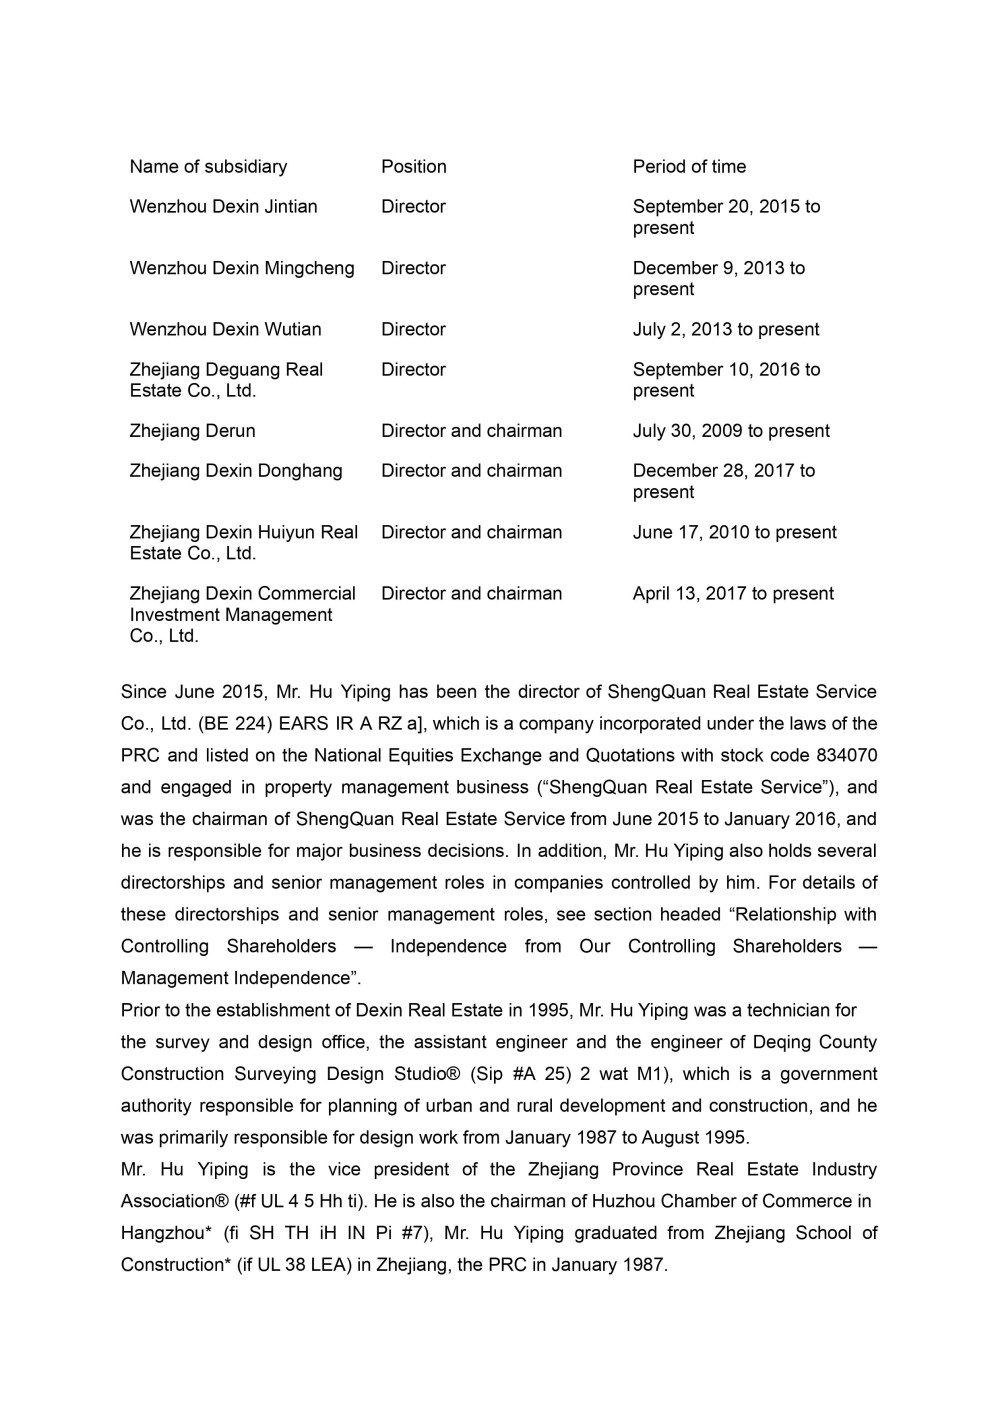

In [13]:
image_raw = spark.read.format("binaryFile").load("data/keeplayout/formLayoutText3.jpg").cache()
example_df = BinaryToImage().transform(image_raw)
display_images(example_df)

In [14]:
%%html   
<style type='text/css'>
.CodeMirror{
font-size: 15px;
}

div.output_area pre {
    font-size: 10px;

</style>

## Sample of missing formatting during OCR on image

In [15]:
def pipeline_nolayout():
    skew =  ImageSkewCorrector() \
        .setInputCol("image") \
        .setOutputCol("corrected_image") \
        .setAutomaticSkewCorrection(True)
    
    ocr = ImageToText() \
        .setInputCol("corrected_image") \
        .setOutputCol("text")
    
    pipeline = PipelineModel(stages=[
        skew,
        ocr
    ])
    
    return pipeline

result_bin = pipeline_nolayout().transform(example_df).cache()
print(result_bin.select("text").collect()[0].text)

Name of subsidiary Position Period of time

Wenzhou Dexin Jintian Director September 20, 2015 to
present

Wenzhou Dexin Mingcheng _ Director December 9, 2013 to
present

Wenzhou Dexin Wutian Director July 2, 2013 to present

Zhejiang Deguang Real Director September 10, 2016 to

Estate Co., Ltd. present

Zhejiang Derun Director and chairman July 30, 2009 to present

Zhejiang Dexin Donghang Director and chairman December 28, 2017 to
present

Zhejiang Dexin Huiyun Real Director and chairman June 17, 2010 to present

Estate Co., Ltd.

Zhejiang Dexin Commercial Director and chairman April 13, 2017 to present

Investment Management

Co., Ltd.

Since June 2015, Mr. Hu Yiping has been the director of ShengQuan Real Estate Service
Co., Ltd. (BE 224) EARS IR A RZ a], which is a company incorporated under the laws of the
PRC and listed on the National Equities Exchange and Quotations with stock code 834070
and engaged in property management business (“ShengQuan Real Estate Service”), and
was the 

## Sample of keeping formatting during OCR on image

In [16]:
def pipeline_keeplayout():
    skew =  ImageSkewCorrector() \
        .setInputCol("image") \
        .setOutputCol("corrected_image") \
        .setAutomaticSkewCorrection(True)

    ocr = ImageToText() \
        .setInputCol("corrected_image") \
        .setOutputCol("text") \
        .setOcrParams(["preserve_interword_spaces=1", ]) \
        .setKeepLayout(True) \
        .setOutputSpaceCharacterWidth(8)
    
    pipeline = PipelineModel(stages=[
        skew,
        ocr
    ])
    
    return pipeline

result2 = pipeline_keeplayout().transform(example_df).cache()
print(result2.select("text").collect()[0].text)

                Name   of subsidiary           Position                        Period of time                                
                Wenzhou   Dexin  Jintian       Director                        September   20, 2015 to                       
                                                                               present                                       
                Wenzhou   Dexin  Mingcheng   _ Director                        December   9, 2013 to                         
                                                                               present                                       
                Wenzhou   Dexin  Wutian        Director                        July 2, 2013 to present                       
                Zhejiang Deguang   Real        Director                        September   10, 2016 to                       
                Estate Co., Ltd.                                               present                                